LIBRARIES

In [8]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

INPUTS

In [9]:
IMG_HEIGHT= 227
IMG_WIDTH =227
IMG_CHANNELS = 3
CALSS_NAMES = ["lilly", "lotus", "orchid", "sunflower", "tulip"]

In [10]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    r"C:\My Folder\Projects\Computer_Vision\flower_images\train",
    labels = 'inferred',
    label_mode = 'int',
    image_size = (IMG_HEIGHT, IMG_WIDTH),
    batch_size =16
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    r"C:\My Folder\Projects\Computer_Vision\flower_images\val",
    labels = 'inferred',
    label_mode = 'int',
    image_size = (IMG_HEIGHT, IMG_WIDTH),
    batch_size =16
)

normalize = tf.keras.layers.Rescaling(1./255)
train_dataset = train_dataset.map(lambda x, y: (normalize(x), y))
val_dataset = val_dataset.map(lambda x, y: (normalize(x), y))

Found 3000 files belonging to 5 classes.
Found 1000 files belonging to 5 classes.


NETWORK ARCHITECTURE

In [11]:
alexnet = keras.Sequential([
    keras.layers.Input(shape= (IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),

    keras.layers.Conv2D(96, kernel_size=11, strides =4, activation='relu'),
    keras.layers.MaxPool2D(pool_size =3, strides= 2),

    keras.layers.Conv2D(256, kernel_size= 5, padding='same', activation='relu'),
    keras.layers.MaxPool2D(pool_size=3, strides= 2),

    keras.layers.Conv2D(384, kernel_size=3, padding='same', activation='relu'),
    keras.layers.Conv2D(384, kernel_size =3, padding='same', activation = 'relu'),
    keras.layers.Conv2D(256, kernel_size= 3, padding='same', activation = 'relu'),

    keras.layers.MaxPool2D(pool_size=3, strides=2),
    keras.layers.Flatten(),

    keras.layers.Dense(4096, activation='relu'),
    keras.layers.Dropout(0.5),

    keras.layers.Dense(4096, activation='relu'),
    keras.layers.Dropout(0.5),

    keras.layers.Dense(1000, activation='relu'),
    keras.layers.Dropout(0.5),

    keras.layers.Dense(300, activation = 'relu'),
    keras.layers.Dropout(0.5),
    
    keras.layers.Dense(5, activation='softmax')

])

alexnet.compile(
    optimizer = 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

alexnet.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 55, 55, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 27, 27, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 27, 27, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 13, 13, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 13, 13, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4096)           │    37,752,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1000)           │     4,097,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 300)            │       300,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 5)              │         1,505 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,680,149 (239.11 MB)

 Trainable params: 62,680,149 (239.11 MB)

 Non-trainable params: 0 (0.00 B)

TRAINING

In [12]:
EPOCHS =10
history = alexnet.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs =EPOCHS
)

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 112s 585ms/step - accuracy: 0.1927 - loss: 1.6644 - val_accuracy: 0.2000 - val_loss: 1.6101
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 110s 584ms/step - accuracy: 0.1997 - loss: 1.6112 - val_accuracy: 0.2000 - val_loss: 1.6096
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 111s 591ms/step - accuracy: 0.1900 - loss: 1.6114 - val_accuracy: 0.2000 - val_loss: 1.6095
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 110s 585ms/step - accuracy: 0.1887 - loss: 1.6102 - val_accuracy: 0.2000 - val_loss: 1.6095
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 110s 582ms/step - accuracy: 0.1923 - loss: 1.6113 - val_accuracy: 0.2000 - val_loss: 1.6095
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 117s 624ms/step - accuracy: 0.1833 - loss: 1.6108 - val_accuracy: 0.2000 - val_loss: 1.6095
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 112s 595ms/step - accuracy: 0.1943 - loss: 1.6106 - val_accuracy: 0.2000 - val_loss: 1.6095
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 113s 602ms/step - accuracy: 0.1857 -

PLOTTING

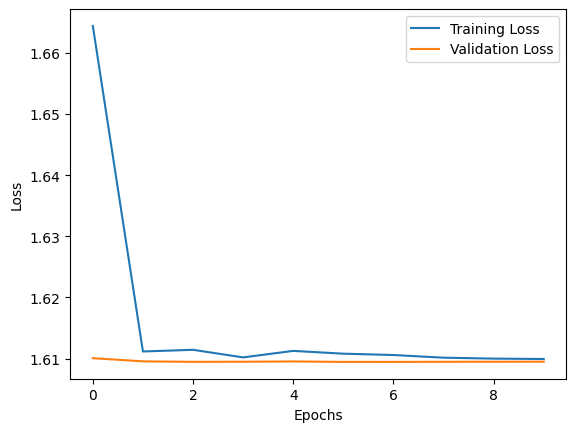

In [13]:
plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

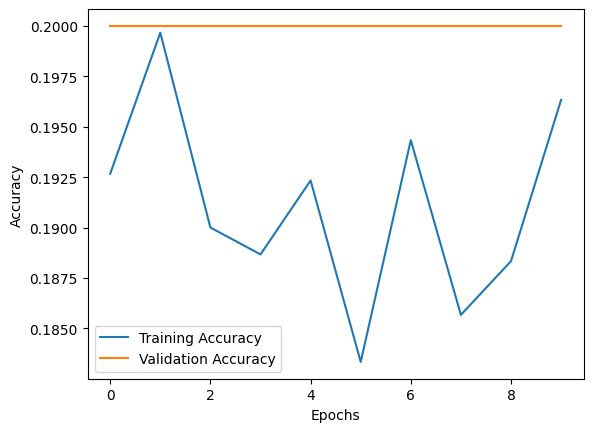

In [14]:
plt.plot(history.history['accuracy'], label="Training Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()